In [10]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

#### Lectura de train y test

In [4]:
df = pd.read_csv(r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\data\processed\dfdefinitivo.csv')
df.head()

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,PI_High,PI_Low,AtR_High,AtR_Low,Exam_Score
0,0,4,7,1,0,0,0,1,9
1,1,27,13,0,0,1,0,0,3
2,1,25,6,1,1,0,0,0,9
3,1,13,11,1,0,0,0,0,2
4,2,23,1,1,0,1,1,0,7


#### Dividimos en train y test

In [44]:
X = df.drop(columns = 'Exam_Score')
poly = PolynomialFeatures(degree = 2)
X = poly.fit_transform(X)
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 30)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 45)
(2000, 45)
(8000,)
(2000,)


In [45]:
X2 = df.drop(columns = 'Exam_Score')
y2 = df['Exam_Score']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2, random_state = 30)

print(X_train2.shape)
print(X_test2.shape)
print(y_train2.shape)
print(y_test2.shape)

(8000, 8)
(2000, 8)
(8000,)
(2000,)


# Cargamos los modelos

In [81]:
model_files = {
    'lassoR': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\lassoR.pkl',
    # 'linear_reg': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\linear_reg.pkl',
    # 'random_forest': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\random_forest.pkl',
    'pol_reg': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\pol_reg.pkl',
    'randomf_gs': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\randomf_gs.pkl',
    'ridgeR': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\ridgeR.pkl'
}

In [82]:
model_files2 = {
    # 'lassoR': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\lassoR.pkl',
    'linear_reg': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\linear_reg.pkl',
    'random_forest': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\random_forest.pkl',
    # 'pol_reg': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\pol_reg.pkl',
    # 'randomf_gs': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\randomf_gs.pkl',
    # 'ridgeR': r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\ridgeR.pkl'
}

In [83]:
models = {}
for name, file in model_files.items():
    with open(file, 'rb') as f:
        models[name] = pickle.load(f)

In [84]:
models2 = {}
for name, file in model_files2.items():
    with open(file, 'rb') as f:
        models2[name] = pickle.load(f)

In [85]:
models

{'lassoR': Lasso(alpha=0.0058),
 'pol_reg': LinearRegression(),
 'randomf_gs': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', RandomForestRegressor(max_depth=10))]),
 'ridgeR': Ridge(alpha=17.07)}

In [86]:
models2

{'linear_reg': LinearRegression(),
 'random_forest': RandomForestRegressor(max_depth=7, min_samples_split=5, random_state=42)}

In [87]:
metrics = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    metrics.append({
        'Modelo': name,
        'R²': r2_score(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    })

In [88]:
metrics2 = []
for name, model in models2.items():
    y_pred2 = model.predict(X_test2)
    metrics2.append({
        'Modelo': name,
        'R²': r2_score(y_test2, y_pred2),
        'MSE': mean_squared_error(y_test2, y_pred2),
        'RMSE': np.sqrt(mean_squared_error(y_test2, y_pred2)),
        'MAE': mean_absolute_error(y_test2, y_pred2)
    })

In [89]:
metrics2

[{'Modelo': 'linear_reg',
  'R²': 0.9705117599867098,
  'MSE': 24.470107306272777,
  'RMSE': np.float64(4.946726928613786),
  'MAE': 4.035224815108551},
 {'Modelo': 'random_forest',
  'R²': 0.9802217277832995,
  'MSE': 16.412523882646422,
  'RMSE': np.float64(4.051237327366347),
  'MAE': 3.279756627865798}]

In [90]:
metrics

[{'Modelo': 'lassoR',
  'R²': 0.9720251799987366,
  'MSE': 23.21423208018043,
  'RMSE': np.float64(4.818114992419798),
  'MAE': 3.910841066882375},
 {'Modelo': 'pol_reg',
  'R²': 0.9720096722921341,
  'MSE': 23.227100777819487,
  'RMSE': np.float64(4.819450256805177),
  'MAE': 3.910148028012212},
 {'Modelo': 'randomf_gs',
  'R²': 0.980309530220369,
  'MSE': 16.33966314033437,
  'RMSE': np.float64(4.042234918993993),
  'MAE': 3.253803430803127},
 {'Modelo': 'ridgeR',
  'R²': 0.9720101118266105,
  'MSE': 23.226736040697226,
  'RMSE': np.float64(4.81941241653972),
  'MAE': 3.910300079219069}]

In [93]:
metrics_df = pd.DataFrame(metrics).set_index('Modelo')
metrics_df2 = pd.DataFrame(metrics2).set_index('Modelo')
metrics_df = pd.concat([metrics_df, metrics_df2])
metrics_df

,R²,MSE,RMSE,MAE
Modelo,,,,
lassoR,0.972025,23.214232,4.818115,3.910841
pol_reg,0.972010,23.227101,4.819450,3.910148
randomf_gs,0.980310,16.339663,4.042235,3.253803
ridgeR,0.972010,23.226736,4.819412,3.910300
linear_reg,0.970512,24.470107,4.946727,4.035225
random_forest,0.980222,16.412524,4.051237,3.279757


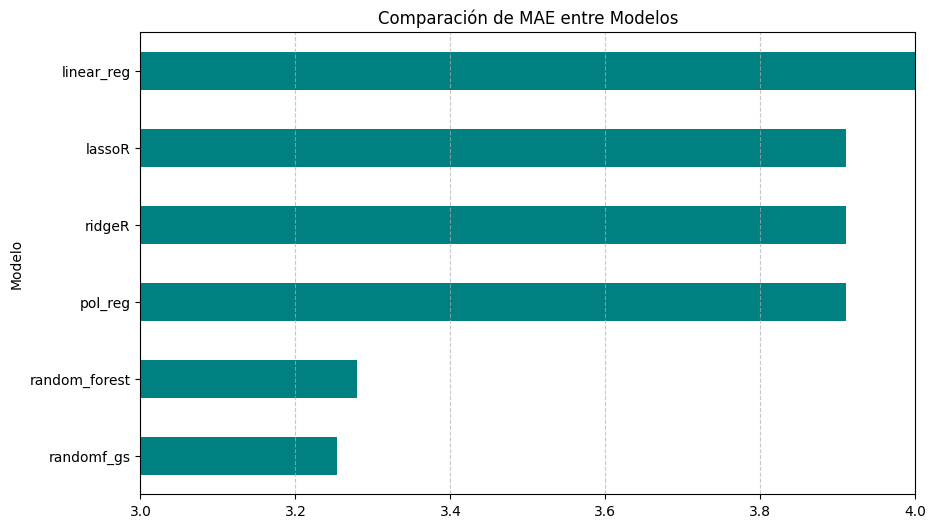

In [121]:
plt.figure(figsize=(10, 6))
metrics_df['MAE'].sort_values().plot(kind='barh', color='teal')
plt.title('Comparación de MAE entre Modelos')
plt.xlim(3, 4)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

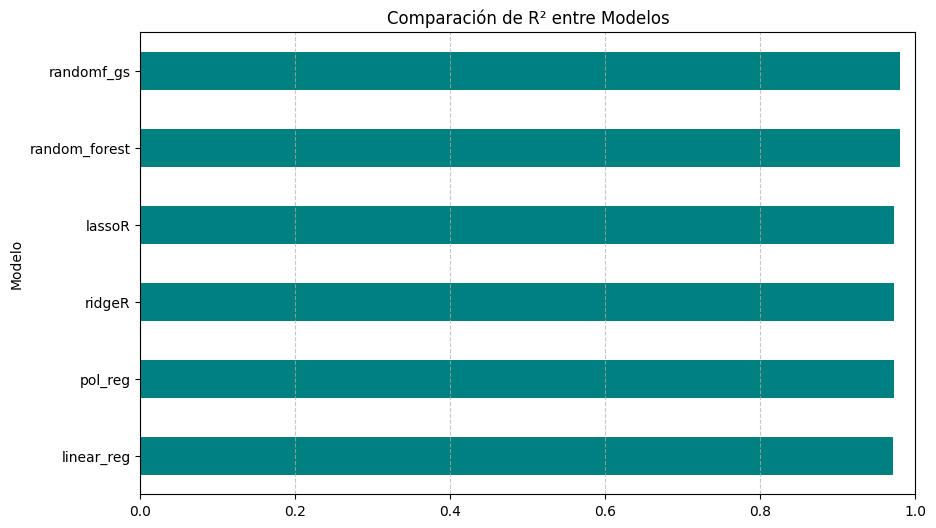

In [122]:
plt.figure(figsize=(10, 6))
metrics_df['R²'].sort_values().plot(kind='barh', color='teal')
plt.title('Comparación de R² entre Modelos')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

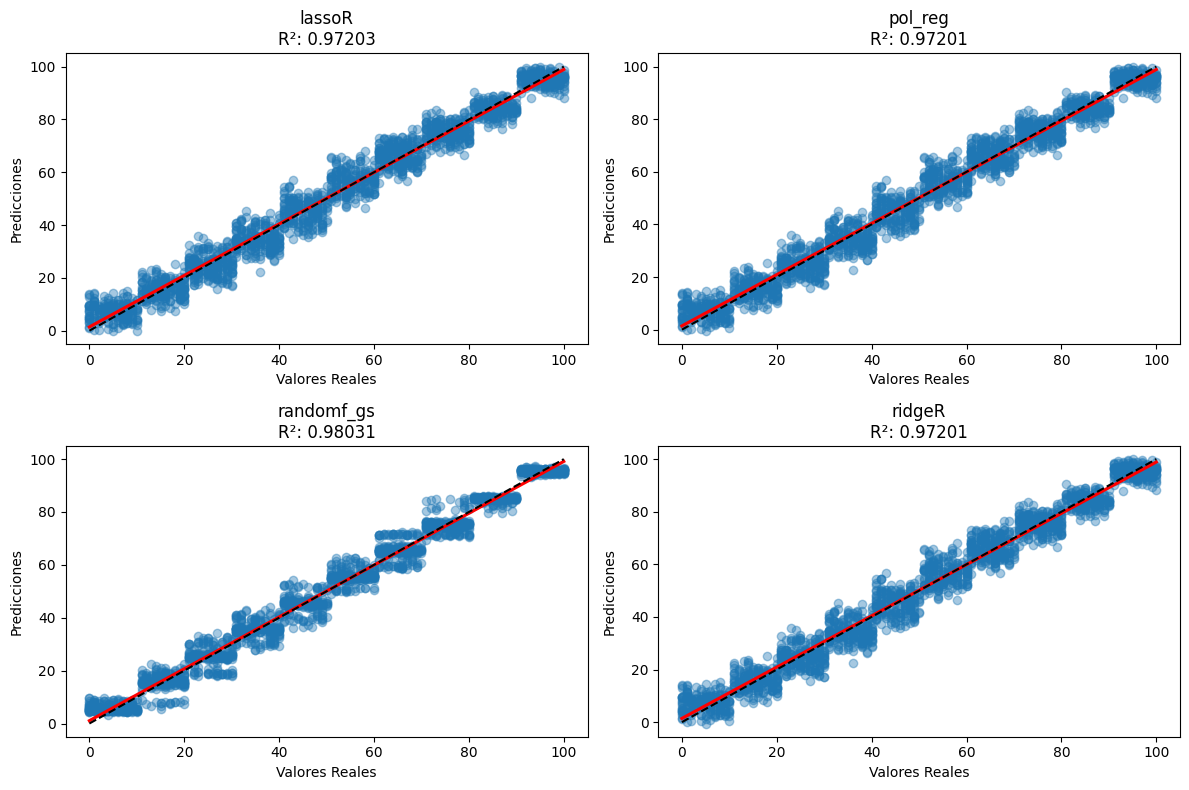

In [103]:
plt.figure(figsize=(12, 8))
for i, (name, model) in enumerate(models.items(), 1):
    y_pred = model.predict(X_test)
    
    plt.subplot(2, 2, i)
    sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
    plt.xlabel('Valores Reales')
    plt.ylabel('Predicciones')
    plt.title(f'{name}\nR²: {r2_score(y_test, y_pred):.5f}')
    
plt.tight_layout()
plt.show()

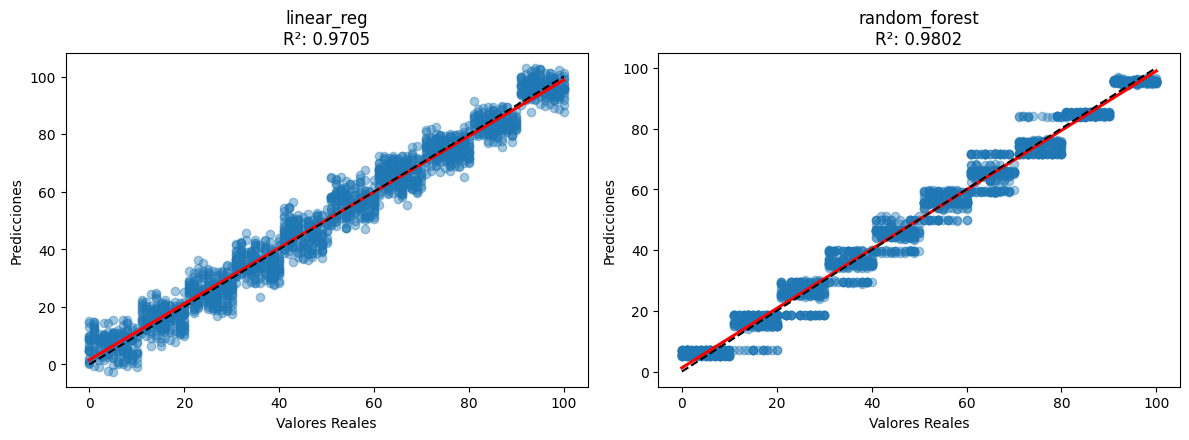

In [101]:
plt.figure(figsize=(12, 8))
for i, (name, model) in enumerate(models2.items(), 1):
    y_pred2 = model.predict(X_test2)
    
    plt.subplot(2, 2, i)
    sns.regplot(x=y_test2, y=y_pred2, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'k--')
    plt.xlabel('Valores Reales')
    plt.ylabel('Predicciones')
    plt.title(f'{name}\nR²: {r2_score(y_test2, y_pred2):.4f}')
    
plt.tight_layout()
plt.show()

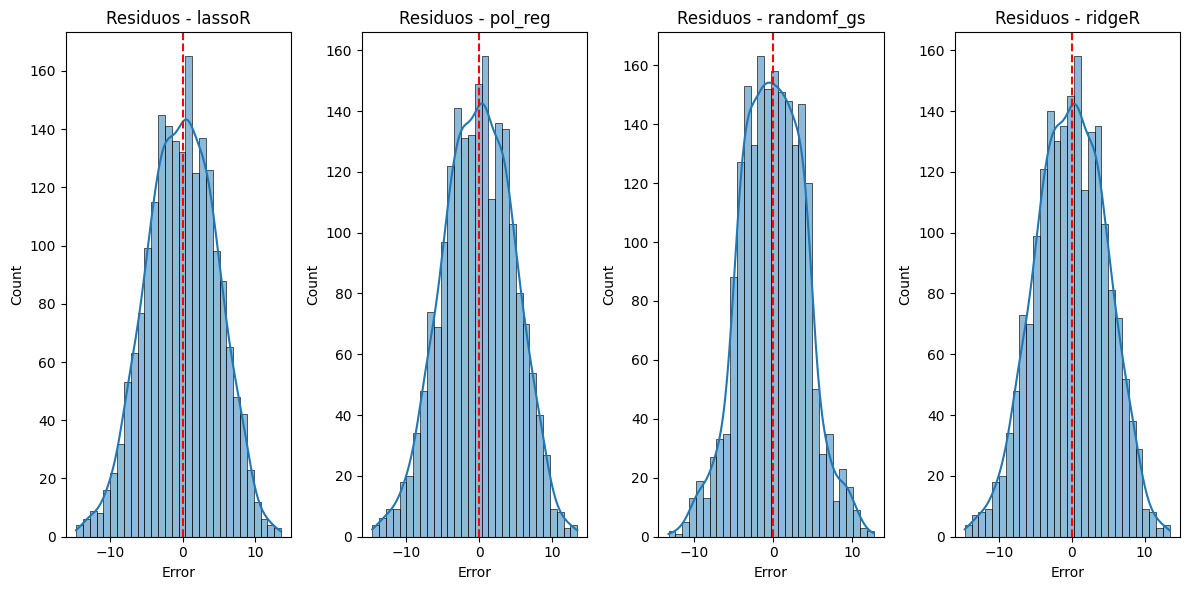

In [104]:
plt.figure(figsize=(12, 6))
for i, (name, model) in enumerate(models.items(), 1):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    
    plt.subplot(1, len(models), i)
    sns.histplot(residuals, kde=True, bins=30)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title(f'Residuos - {name}')
    plt.xlabel('Error')

plt.tight_layout()
plt.show()

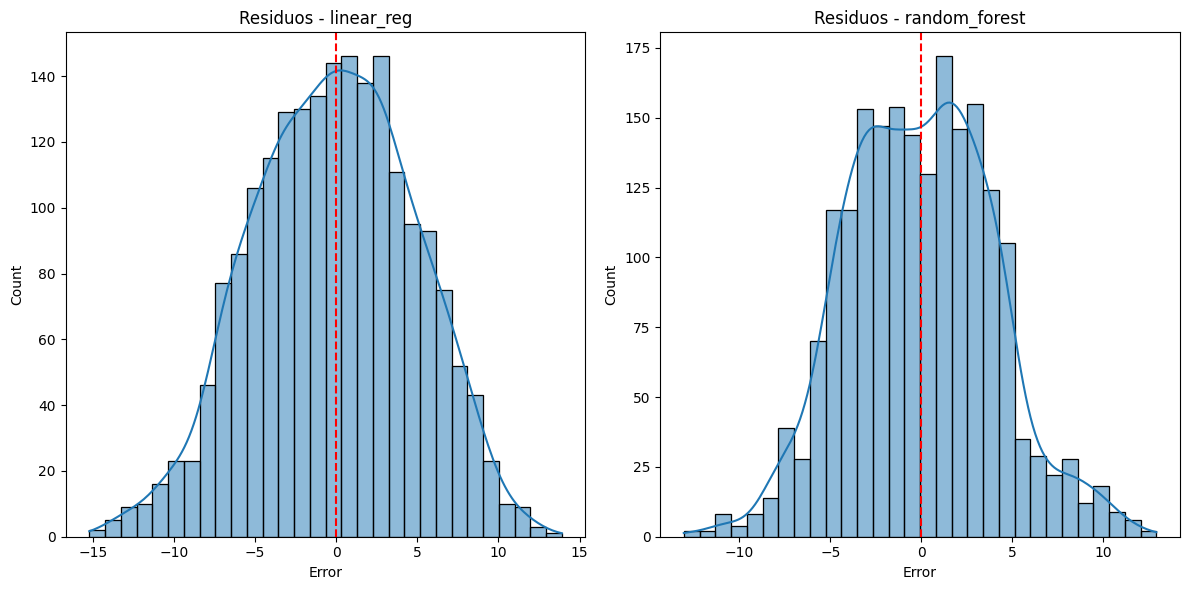

In [105]:
plt.figure(figsize=(12, 6))
for i, (name, model) in enumerate(models2.items(), 1):
    y_pred2 = model.predict(X_test2)
    residuals2 = y_test2 - y_pred2
    
    plt.subplot(1, len(models2), i)
    sns.histplot(residuals2, kde=True, bins=30)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title(f'Residuos - {name}')
    plt.xlabel('Error')

plt.tight_layout()
plt.show()

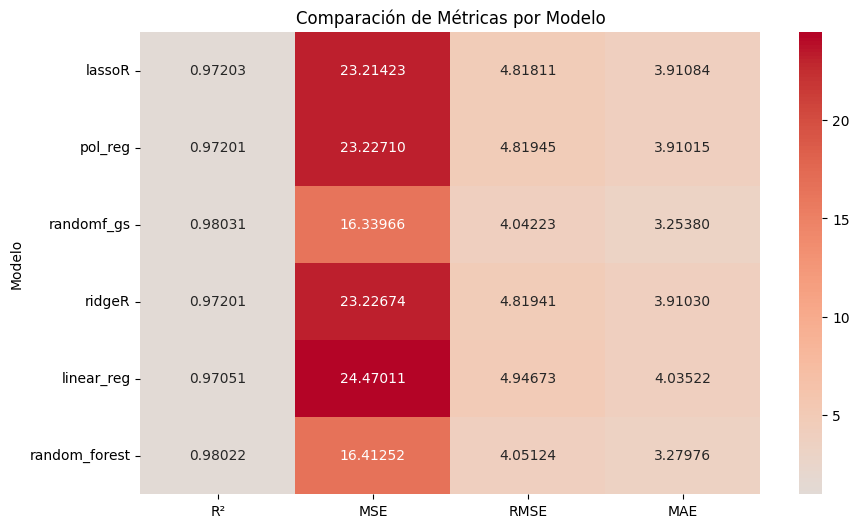

In [114]:
plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, annot=True, cmap='coolwarm', fmt='.5f', center=0)
plt.title('Comparación de Métricas por Modelo')
plt.show()

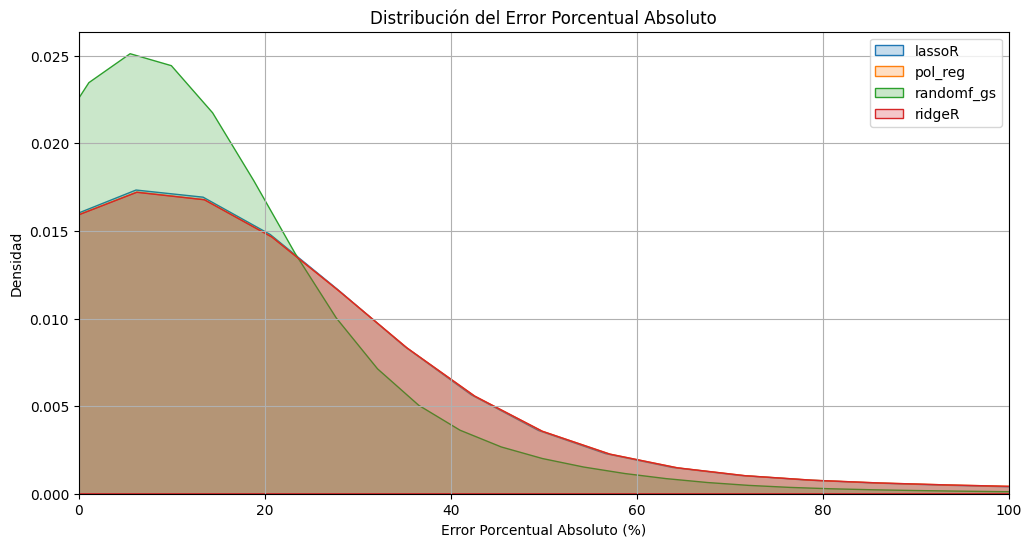

In [107]:
plt.figure(figsize=(12, 6))
for name, model in models.items():
    y_pred = model.predict(X_test)
    ape = 100 * np.abs((y_test - y_pred) / y_test)  
    sns.kdeplot(ape, label=name, fill=True)

plt.xlim(0, 100)
plt.xlabel('Error Porcentual Absoluto (%)')
plt.ylabel('Densidad')
plt.title('Distribución del Error Porcentual Absoluto')
plt.legend()
plt.grid()
plt.show()

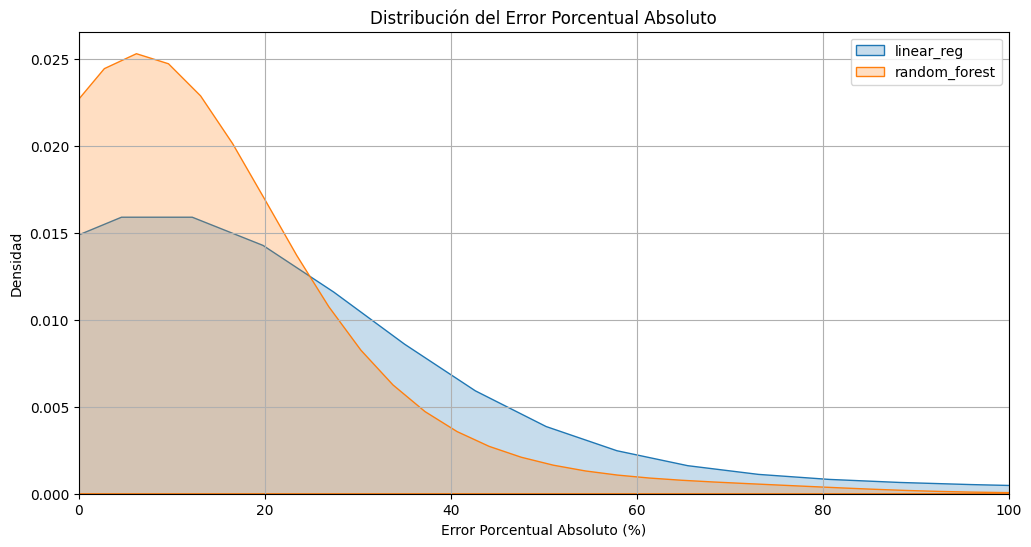

In [108]:
plt.figure(figsize=(12, 6))
for name, model in models2.items():
    y_pred2 = model.predict(X_test2)
    ape2 = 100 * np.abs((y_test2 - y_pred2) / y_test2)  
    sns.kdeplot(ape2, label=name, fill=True)

plt.xlim(0, 100)
plt.xlabel('Error Porcentual Absoluto (%)')
plt.ylabel('Densidad')
plt.title('Distribución del Error Porcentual Absoluto')
plt.legend()
plt.grid()
plt.show()

C:\Users\plaza\AppData\Local\Temp\ipykernel_39740\725439692.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=normalized['Score'], y=normalized.index, palette='viridis')


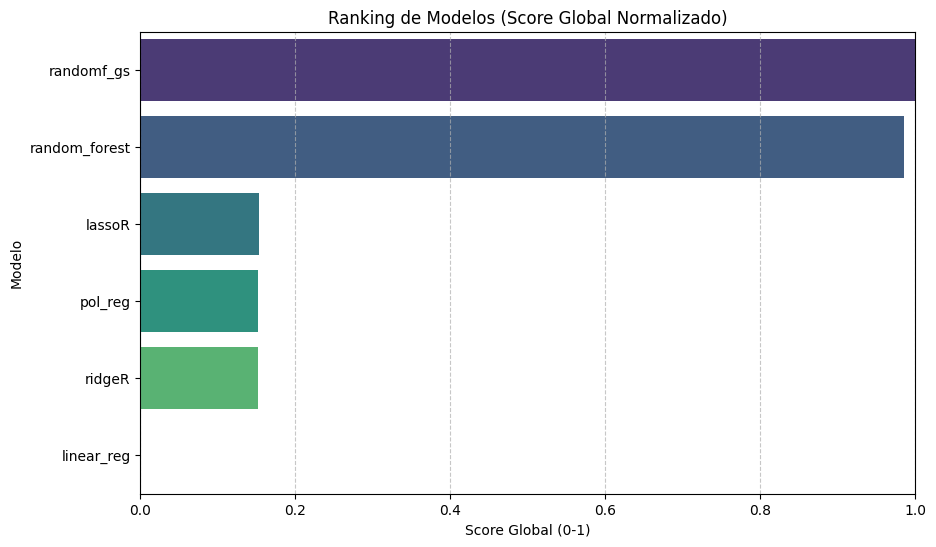

In [ ]:
normalized = metrics_df.copy()
for col in normalized.columns:
    if col == 'R²':  
        normalized[col] = (normalized[col] - normalized[col].min()) / (normalized[col].max() - normalized[col].min())
    else:  
        normalized[col] = 1 - (normalized[col] - normalized[col].min()) / (normalized[col].max() - normalized[col].min())

normalized['Score'] = normalized.mean(axis=1)

normalized = normalized.sort_values('Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=normalized['Score'], y=normalized.index, palette='viridis')
plt.title('Ranking de Modelos (Score Global Normalizado)')
plt.xlabel('Score Global (0-1)')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()